In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/NeuraSight/brainMRI.zip"

print("Exists:", os.path.exists(dataset_path))

Exists: True


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/NeuraSight/brainMRI.zip"

extract_path = "/content/brainMRI"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [ ]:
import os

for root, dirs, files in os.walk("/content/brainMRI"):
    print(root)

/content/brainMRI
/content/brainMRI/Testing
/content/brainMRI/Testing/notumor
/content/brainMRI/Testing/glioma
/content/brainMRI/Testing/pituitary
/content/brainMRI/Testing/meningioma
/content/brainMRI/Training
/content/brainMRI/Training/notumor
/content/brainMRI/Training/glioma
/content/brainMRI/Training/pituitary
/content/brainMRI/Training/meningioma


In [ ]:
!pip install timm
!pip install grad-cam
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=918f4dda3675c731f4f8f6213c5d0f313868be3a80bff70ab38da839ed0be29e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import os
import numpy as np
import pandas as pd

import torch
import torchvision

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [ ]:
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
train_dir = "/content/brainMRI/Training"
test_dir = "/content/brainMRI/Testing"

print("TRAINING DATASET")
print("-"*40)

for cls in os.listdir(train_dir):
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"{cls}: {count}")

print("\nTESTING DATASET")
print("-"*40)

for cls in os.listdir(test_dir):
    count = len(os.listdir(os.path.join(test_dir, cls)))
    print(f"{cls}: {count}")

TRAINING DATASET
----------------------------------------
notumor: 1400
glioma: 1400
pituitary: 1400
meningioma: 1400

TESTING DATASET
----------------------------------------
notumor: 400
glioma: 400
pituitary: 400
meningioma: 400


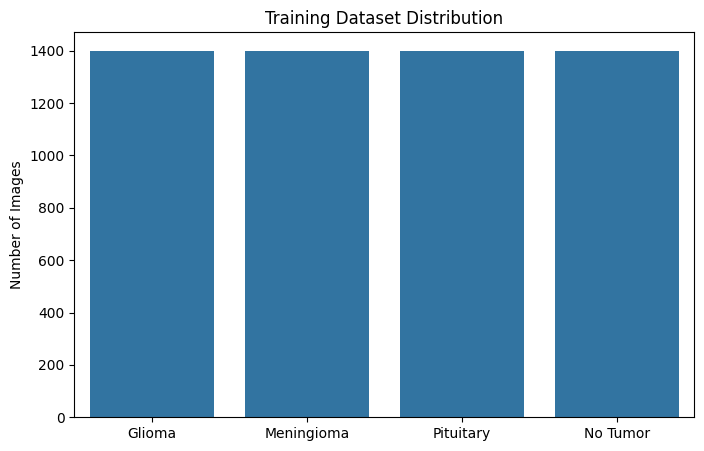

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

classes = ["Glioma","Meningioma","Pituitary","No Tumor"]

counts = [1400,1400,1400,1400]

plt.figure(figsize=(8,5))

sns.barplot(
    x=classes,
    y=counts
)

plt.title("Training Dataset Distribution")
plt.ylabel("Number of Images")

plt.show()

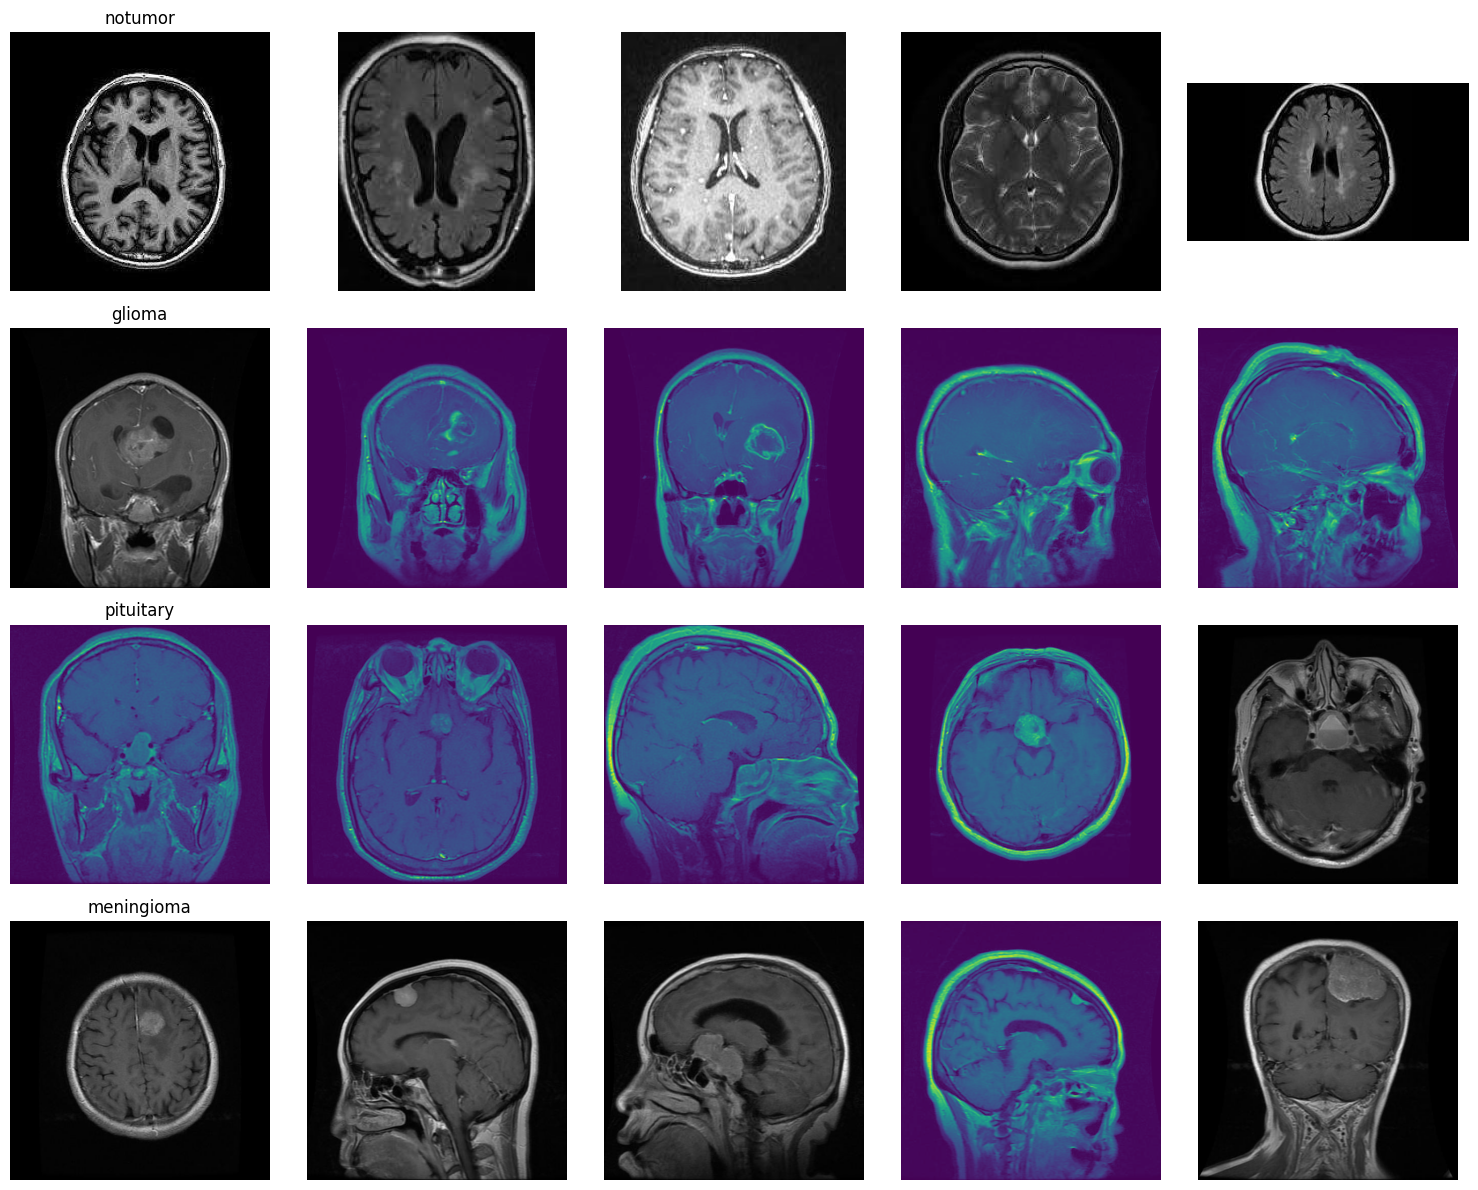

In [ ]:
import random
from PIL import Image

fig, axes = plt.subplots(
    4,
    5,
    figsize=(15,12)
)

for row, cls in enumerate(os.listdir(train_dir)):

    class_path = os.path.join(
        train_dir,
        cls
    )

    samples = random.sample(
        os.listdir(class_path),
        5
    )

    for col, img_name in enumerate(samples):

        img_path = os.path.join(
            class_path,
            img_name
        )

        img = Image.open(img_path)

        axes[row,col].imshow(img)
        axes[row,col].axis("off")

        if col == 0:
            axes[row,col].set_title(cls)

plt.tight_layout()
plt.show()

In [ ]:
widths = []
heights = []

for cls in os.listdir(train_dir):

    class_path = os.path.join(
        train_dir,
        cls
    )

    for img_name in os.listdir(class_path):

        img_path = os.path.join(
            class_path,
            img_name
        )

        img = Image.open(img_path)

        widths.append(img.size[0])
        heights.append(img.size[1])

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height:", min(heights))
print("Maximum Height:", max(heights))

print("Average Width :", np.mean(widths))
print("Average Height:", np.mean(heights))

Minimum Width : 150
Maximum Width : 1375
Minimum Height: 168
Maximum Height: 1446
Average Width : 458.51375
Average Height: 462.2628571428571


In [ ]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    train_dir,
    transform=train_transform
)

test_dataset = ImageFolder(
    test_dir,
    transform=test_transform
)

print(train_dataset.classes)

print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

['glioma', 'meningioma', 'notumor', 'pituitary']
Training Images: 5600
Testing Images: 1600


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 175
Test batches: 50


In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
!pip install timm -q

In [ ]:
import timm

import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [ ]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=4
)

model = model.to(device)

print("Model Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model Loaded Successfully


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001
)

In [ ]:
EPOCHS = 10

best_accuracy = 0

In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    loss = running_loss / len(loader)

    accuracy = 100 * correct / total

    return loss, accuracy

In [ ]:
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    loss = running_loss / len(loader)

    accuracy = 100 * correct / total

    return loss, accuracy

In [ ]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print(
            "Best model saved!"
        )

Epoch 1/10
Train Loss: 0.5928 | Train Acc: 83.82%
Val Loss: 0.5894 | Val Acc: 88.56%
Best model saved!
Epoch 2/10
Train Loss: 0.1572 | Train Acc: 94.36%
Val Loss: 0.5160 | Val Acc: 91.88%
Best model saved!
Epoch 3/10
Train Loss: 0.0700 | Train Acc: 97.41%
Val Loss: 0.6055 | Val Acc: 92.56%
Best model saved!
Epoch 4/10
Train Loss: 0.0585 | Train Acc: 97.93%
Val Loss: 0.5613 | Val Acc: 93.81%
Best model saved!
Epoch 5/10
Train Loss: 0.0414 | Train Acc: 98.59%
Val Loss: 0.5871 | Val Acc: 93.75%
Epoch 6/10
Train Loss: 0.0343 | Train Acc: 98.82%
Val Loss: 0.6172 | Val Acc: 94.31%
Best model saved!
Epoch 7/10
Train Loss: 0.0267 | Train Acc: 99.16%
Val Loss: 0.6516 | Val Acc: 94.25%
Epoch 8/10
Train Loss: 0.0224 | Train Acc: 99.29%
Val Loss: 0.5664 | Val Acc: 94.44%
Best model saved!
Epoch 9/10
Train Loss: 0.0212 | Train Acc: 99.38%
Val Loss: 0.5768 | Val Acc: 95.00%
Best model saved!
Epoch 10/10
Train Loss: 0.0183 | Train Acc: 99.41%
Val Loss: 0.6194 | Val Acc: 94.62%


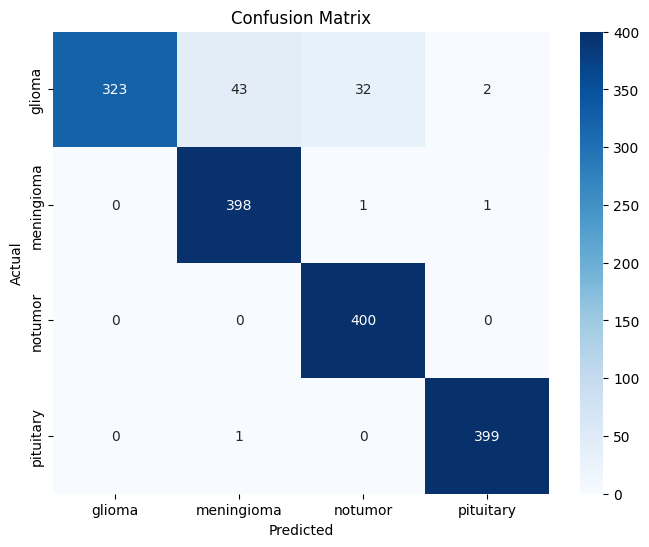

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.load_state_dict(
    torch.load("best_model.pth")
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes
    )
)

              precision    recall  f1-score   support

      glioma       1.00      0.81      0.89       400
  meningioma       0.90      0.99      0.95       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



In [ ]:
import os

print(os.getcwd())

print(os.path.exists("best_model.pth"))

/content
True


In [ ]:
import os

size = os.path.getsize("best_model.pth")

print(size / 1024 / 1024, "MB")

15.589104652404785 MB


In [ ]:
from google.colab import files

files.download("best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil

shutil.copy(
    "best_model.pth",
    "/content/drive/MyDrive/NeuraSight/best_model.pth"
)

print("Saved to Drive")

Saved to Drive


In [ ]:
torch.save(
    model,
    "neurasight_model.pt"
)

In [ ]:
import shutil

shutil.copy(
    "neurasight_model.pt",
    "/content/drive/MyDrive/NeuraSight/"
)

'/content/drive/MyDrive/NeuraSight/neurasight_model.pt'

In [ ]:
import os

print("Current Directory:")
print(os.getcwd())

print("\nPTH Files Found:")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))


Current Directory:
/content

PTH Files Found:
/content/best_model.pth
/content/drive/MyDrive/DeadCode/segmentation_head.pth
/content/drive/MyDrive/DeadCode/best_model_max_accuracy.pth
/content/drive/MyDrive/NeuraSight/best_model.pth
